# Tutorial 1 — Molecular Fingerprints & Tanimoto Similarity
**Author:** Himanshu Goel | [Website](https://himanshugoel.github.io) | [GitHub](https://github.com/himanshugoel)

Molecular fingerprints are binary bit-vectors that encode the presence or absence of structural features. They are the backbone of similarity search, compound clustering, and many ML models in drug discovery.

In this tutorial we cover:
- Morgan fingerprints (ECFP)
- Tanimoto similarity
- Similarity matrix heatmap
- Nearest-neighbour search in a compound library

In [ ]:
# Install dependencies (Colab)
!pip install rdkit pandas numpy matplotlib seaborn -q

## 1. Load molecules from SMILES

In [6]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, Draw
from rdkit.Chem import rdMolDescriptors
import pandas as pd
import numpy as np

smiles_dict = {
    "Aspirin":      "CC(=O)Oc1ccccc1C(=O)O",
    "Ibuprofen":    "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Paracetamol":  "CC(=O)Nc1ccc(O)cc1",
    "Caffeine":     "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "Morphine":     "OC1=CC=C2CC3N(CCC34CCc5c4cc(O)c(OC)c5)C2=C1",
    "Terfenadine":  "OC(c1ccc(C(c2ccccc2)(c2ccccc2)O)cc1)CCCN1CCC(CC1)C(O)(c1ccccc1)c1ccccc1",
    "Cisapride":    "CCOC(=O)c1cc2cc(OC)c(OC)cc2[nH]1",
    "Metformin":    "CN(C)C(=N)NC(=N)N",
    "Atorvastatin": "CC(C)c1c(C(=O)Nc2ccccc2)c(-c2ccccc2)c(-c2ccc(F)cc2)n1CCC(O)CC(O)CC(=O)O",
    "Dopamine":     "NCCc1ccc(O)c(O)c1",
}

mols = {name: Chem.MolFromSmiles(smi) for name, smi in smiles_dict.items()}
print(f"Loaded {len(mols)} molecules")
for name, mol in mols.items():
    print(f"  {name}: {mol.GetNumAtoms()} atoms, {mol.GetNumBonds()} bonds")

for name, mol in mols.items():
    print(f"{name}:")
    print(Chem.MolToSmiles(mol))

Loaded 10 molecules
  Aspirin: 13 atoms, 13 bonds
  Ibuprofen: 15 atoms, 15 bonds
  Paracetamol: 11 atoms, 11 bonds
  Caffeine: 14 atoms, 15 bonds
  Morphine: 24 atoms, 28 bonds
  Terfenadine: 45 atoms, 50 bonds
  Cisapride: 18 atoms, 19 bonds
  Metformin: 9 atoms, 8 bonds
  Atorvastatin: 41 atoms, 44 bonds
  Dopamine: 11 atoms, 11 bonds
Aspirin:
CC(=O)Oc1ccccc1C(=O)O
Ibuprofen:
CC(C)Cc1ccc(C(C)C(=O)O)cc1
Paracetamol:
CC(=O)Nc1ccc(O)cc1
Caffeine:
Cn1c(=O)c2c(ncn2C)n(C)c1=O
Morphine:
COc1cc2c(cc1O)C1(CC2)CCN2c3cc(O)ccc3CC21
Terfenadine:
OC(CCCN1CCC(C(O)(c2ccccc2)c2ccccc2)CC1)c1ccc(C(O)(c2ccccc2)c2ccccc2)cc1
Cisapride:
CCOC(=O)c1cc2cc(OC)c(OC)cc2[nH]1
Metformin:
CN(C)C(=N)NC(=N)N
Atorvastatin:
CC(C)c1c(C(=O)Nc2ccccc2)c(-c2ccccc2)c(-c2ccc(F)cc2)n1CCC(O)CC(O)CC(=O)O
Dopamine:
NCCc1ccc(O)c(O)c1


## 2. Generate Morgan fingerprints (ECFP4)

In [5]:
# radius=2 → ECFP4, fpSize=2048
from rdkit.Chem import rdFingerprintGenerator
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps = {name: morgan_gen.GetFingerprint(mol) for name, mol in mols.items()}

# Show bit count (density) for each molecule
for name, fp in fps.items():
    n_on = sum(fp)
    print(f"  {name:15s}: {n_on:4d} / 2048 bits set ({n_on/2048*100:.1f}%)")

  Aspirin        :   24 / 2048 bits set (1.2%)
  Ibuprofen      :   25 / 2048 bits set (1.2%)
  Paracetamol    :   20 / 2048 bits set (1.0%)
  Caffeine       :   25 / 2048 bits set (1.2%)
  Morphine       :   47 / 2048 bits set (2.3%)
  Terfenadine    :   42 / 2048 bits set (2.1%)
  Cisapride      :   33 / 2048 bits set (1.6%)
  Metformin      :   17 / 2048 bits set (0.8%)
  Atorvastatin   :   57 / 2048 bits set (2.8%)
  Dopamine       :   21 / 2048 bits set (1.0%)


## 3. Tanimoto similarity matrix

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

names = list(fps.keys())
n = len(names)
sim_matrix = np.zeros((n, n))

for i, n1 in enumerate(names):
    for j, n2 in enumerate(names):
        sim_matrix[i, j] = DataStructs.TanimotoSimilarity(fps[n1], fps[n2])

sim_df = pd.DataFrame(sim_matrix, index=names, columns=names)
print(sim_df.round(5).to_string())

              Aspirin  Ibuprofen  Paracetamol  Caffeine  Morphine  Terfenadine  Cisapride  Metformin  Atorvastatin  Dopamine
Aspirin       1.00000    0.19512      0.22222   0.08889   0.10938      0.11864    0.16327    0.05128       0.15714   0.09756
Ibuprofen     0.19512    1.00000      0.18421   0.08696   0.07463      0.15517    0.13725    0.05000       0.15493   0.17949
Paracetamol   0.22222    0.18421      1.00000   0.09756   0.13559      0.06897    0.12766    0.08824       0.16667   0.13889
Caffeine      0.08889    0.08696      0.09756   1.00000   0.05882      0.06349    0.07407    0.02439       0.07895   0.04545
Morphine      0.10938    0.07463      0.13559   0.05882   1.00000      0.09877    0.14286    0.03226       0.06122   0.11475
Terfenadine   0.11864    0.15517      0.06897   0.06349   0.09877      1.00000    0.05634    0.01724       0.15116   0.08621
Cisapride     0.16327    0.13725      0.12766   0.07407   0.14286      0.05634    1.00000    0.04167       0.08434   0.10204


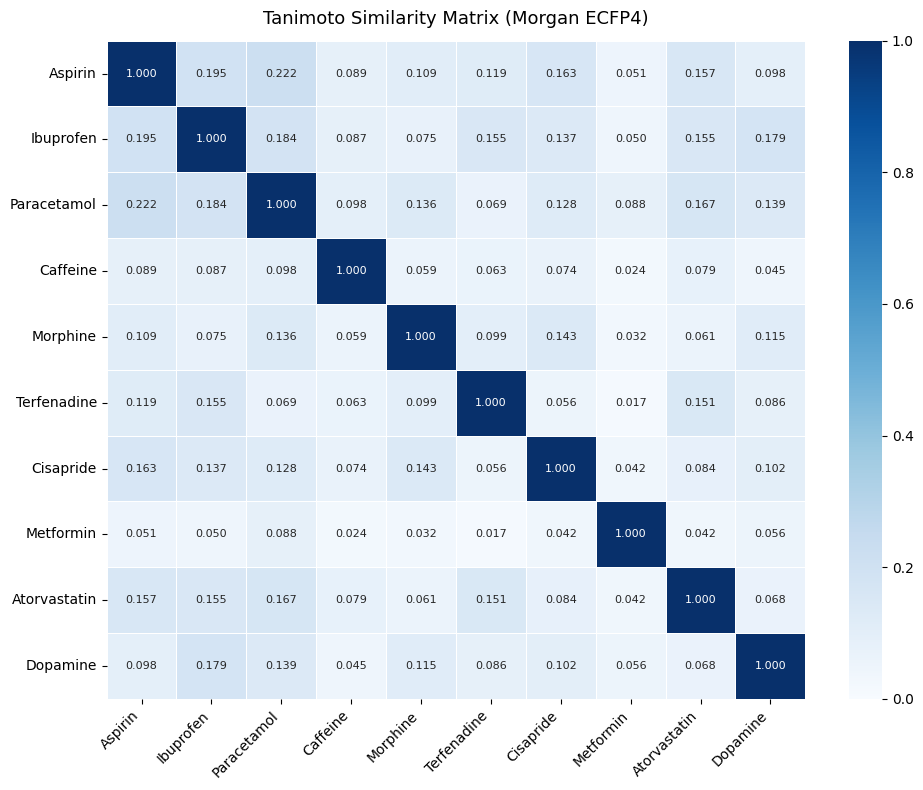

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_df, annot=True, fmt=".3f", cmap="Blues",
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            annot_kws={"size": 8})
ax.set_title("Tanimoto Similarity Matrix (Morgan ECFP4)", fontsize=13, pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("tanimoto_heatmap.png", dpi=150)
plt.show()

## 4. Nearest-neighbour search

In [16]:
def find_nearest(query_name, fps_dict, top_k=3):
    query_fp = fps_dict[query_name]
    sims = {name: DataStructs.TanimotoSimilarity(query_fp, fp)
            for name, fp in fps_dict.items() if name != query_name}
    ranked = sorted(sims.items(), key=lambda x: x[1], reverse=True)
    print(f"\nNearest neighbours to {query_name}:")
    for name, sim in ranked[:top_k]:
        print(f"  {name:15s} Tanimoto = {sim:.3f}")

for q in ["Aspirin", "Morphine", "Caffeine"]:
    find_nearest(q, fps)


Nearest neighbours to Aspirin:
  Paracetamol     Tanimoto = 0.222
  Ibuprofen       Tanimoto = 0.195
  Cisapride       Tanimoto = 0.163

Nearest neighbours to Morphine:
  Cisapride       Tanimoto = 0.143
  Paracetamol     Tanimoto = 0.136
  Dopamine        Tanimoto = 0.115

Nearest neighbours to Caffeine:
  Paracetamol     Tanimoto = 0.098
  Aspirin         Tanimoto = 0.089
  Ibuprofen       Tanimoto = 0.087


## Key takeaways
- Morgan fingerprints encode local atomic environments at a given radius
- Tanimoto similarity of 1.0 = identical fingerprint; 0.0 = no overlap
- Structurally similar compounds cluster together — but biological activity can diverge (activity cliffs)
- High Tanimoto (>0.85) generally means very similar structure; <0.3 means structurally unrelated